# 10 — Наклонные трендовые линии (диагональные уровни)

Ретейл рисует луч через 2 пивота и торгует от него (откуп у восходящей поддержки /
шорт у нисходящего сопротивления). Уровень тот же феномен, но ДВИЖЕТСЯ во времени.

**Причинно:** линия = через две ПОСЛЕДНИЕ подтверждённые свинг-точки (низы для up,
вершины для down), оба пивота подтверждены (лаг k) → проецируем вперёд. Механически
(две последние), без выбора «которые лучше сработали» = без anchor-lookahead. Живёт до
пробоя (close за линией) / перерисовки новым пивотом / лимита возраста.

**Контроль (урок nb06/09):** параллельная линия, тот же наклон, случайный сдвиг цены
(не на реальных пивотах). real vs matched. **train 2024 / test 2025-26.**

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
rng = np.random.default_rng(0)
full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::4][:35]
START, END, TF = "2024-01-01", "2026-07-01", "1h"
K = 10; TOL = 0.002; BREAK = 0.003; LIFE = 480; CD = 6; COST = 0.0015
HZ = [12, 24]; HMAX = 24; SPLIT = pd.Timestamp("2025-01-01", tz="UTC")
print(len(UNIV), "symbols")

35 symbols


In [2]:
def pivots(df, k=K):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i-k:i+k+1]; wL = l[i-k:i+k+1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def build_segs(df, side, k=K, life=LIFE):
    """Trendline segments from consecutive same-type confirmed pivots, projected.
    Returns (i1,p1,i2,p2,slope,start,end) with end = next-pivot-conf or life cap."""
    hi, lo = pivots(df, k); n = len(df)
    pr = df["low"].to_numpy() if side == "up" else df["high"].to_numpy()
    idx = np.where(lo if side == "up" else hi)[0]
    piv = [(int(i), float(pr[i])) for i in idx]
    segs = []
    for j in range(1, len(piv)):
        (i1, p1), (i2, p2) = piv[j-1], piv[j]
        if side == "up" and not (p2 > p1): continue     # rising lows = up support
        if side == "down" and not (p2 < p1): continue   # falling highs = down resistance
        slope = (p2 - p1) / (i2 - i1)
        start = i2 + k                                   # both pivots confirmed
        nxt = (piv[j+1][0] + k) if j+1 < len(piv) else n
        segs.append((i1, p1, i2, p2, slope, start, min(nxt, start + life, n)))
    return segs

def scan(df, segs, side, offset=0.0, tol=TOL, brk=BREAK):
    """Touches of the projected line (optionally price-shifted by offset for control).
    Breaks the line on a close beyond it. Returns (t, side, linevalue)."""
    C = df["close"].to_numpy(); H = df["high"].to_numpy(); L = df["low"].to_numpy()
    ev = []
    for (i1, p1, i2, p2, slope, start, end) in segs:
        off = offset
        for t in range(max(start, 1), end):
            lv = (p2 + slope * (t - i2)) * (1 + off)
            if lv <= 0: continue
            if side == "up":
                if C[t] < lv * (1 - brk): break                        # support broken
                if C[t-1] > lv * (1 + tol) and L[t] <= lv * (1 + tol): ev.append((t, "up", lv))
            else:
                if C[t] > lv * (1 + brk): break                        # resistance broken
                if C[t-1] < lv * (1 - tol) and H[t] >= lv * (1 - tol): ev.append((t, "down", lv))
    return ev

def dedup(ev, cd=CD):
    ev = sorted(ev); out = []; last = -10**9
    for t, s, lv in ev:
        if t - last >= cd: out.append((t, s, lv)); last = t
    return out

[saved] notebooks\levels\_out\10_trendlines.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/10_trendlines.png')

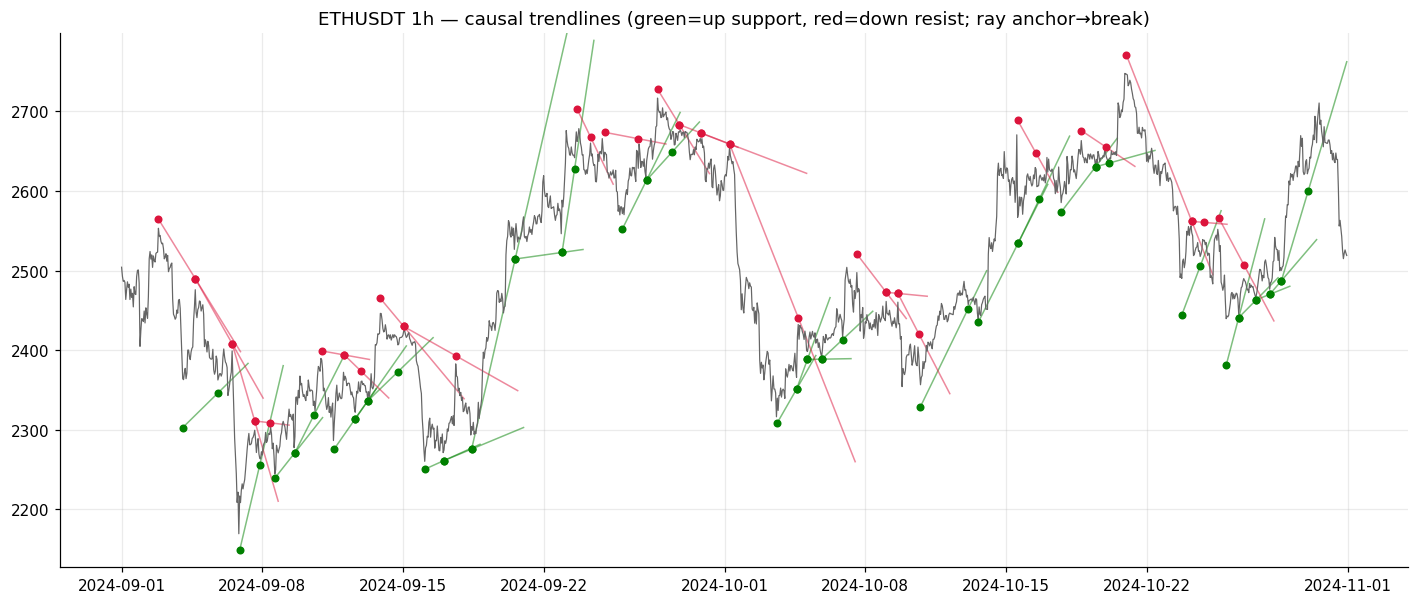

In [3]:
# visualize on one symbol: up-lines (green) / down-lines (red), drawn anchor->break
dv = ohlcv("ETHUSDT", "2024-09-01", "2024-11-01", TF); tv = dv.index; nv = len(dv)
fig, ax = plt.subplots(figsize=(13, 5.6))
ax.plot(tv, dv["close"], lw=0.8, color="0.4", zorder=3)
for side, col in [("up", "green"), ("down", "crimson")]:
    for (i1, p1, i2, p2, slope, start, end) in build_segs(dv, side):
        xe = min(end, nv - 1)
        xs = [tv[i1], tv[xe]]; ys = [p1, p2 + slope * (xe - i2)]
        ax.plot(xs, ys, color=col, lw=1.0, alpha=0.5, zorder=2)
        ax.scatter([tv[i1], tv[i2]], [p1, p2], color=col, s=18, zorder=4)
ax.set_ylim(dv["low"].min()*0.99, dv["high"].max()*1.01)
ax.set_title("ETHUSDT 1h — causal trendlines (green=up support, red=down resist; ray anchor→break)")
show("10_trendlines")

In [4]:
rows = []
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < 300: continue
    c = df["close"].to_numpy(); n = len(df); ts = df.index
    for side in ("up", "down"):
        segs = build_segs(df, side)
        if not segs: continue
        off = rng.choice([-1, 1]) * rng.uniform(0.015, 0.05)   # matched: parallel line, random price shift
        for kind, o in [("real", 0.0), ("matched", off)]:
            for t, sd, lv in dedup(scan(df, segs, side, offset=o)):
                if t + HMAX >= n: continue
                row = dict(kind=kind, side=side, period=("train" if ts[t] < SPLIT else "test"))
                for hh in HZ:
                    rr = c[t+hh]/c[t] - 1.0
                    row[f"h{hh}"] = rr if sd == "up" else -rr   # up support->long, down resist->short
                rows.append(row)
    if (si+1) % 10 == 0: print(f"  {si+1}/{len(UNIV)}")
E = pd.DataFrame(rows)
print("\nevents:")
print(E.groupby(["period", "kind"]).size().unstack().to_string())

  10/35


  20/35


  30/35



events:
kind    matched  real
period               
test       4294  8764
train      3508  6314


In [5]:
print("=== net signed edge (gross - cost), real vs matched, by period & side ===")
for per in ["train", "test"]:
    sub = E[E.period == per]
    t = sub.groupby(["kind", "side"]).agg(n=("h12","size"),
          net12=("h12", lambda s:(s.mean()-COST)*100),
          net24=("h24", lambda s:(s.mean()-COST)*100),
          ms12=("h12", lambda s: s.mean()/s.std() if s.std()>0 else np.nan))
    print(f"\n[{per}]"); print(t.round(3).to_string())
# overall real vs matched per period
print("\n=== overall (both sides) net12 ===")
ov = E.groupby(["period","kind"]).agg(n=("h12","size"), net12=("h12", lambda s:(s.mean()-COST)*100),
        ms12=("h12", lambda s: s.mean()/s.std() if s.std()>0 else np.nan))
print(ov.round(3).to_string())

=== net signed edge (gross - cost), real vs matched, by period & side ===

[train]
                 n  net12  net24   ms12
kind    side                           
matched down  1804 -0.169 -0.294 -0.005
        up    1704  0.032  0.153  0.046
real    down  3171 -0.211 -0.174 -0.015
        up    3143 -0.123 -0.193  0.007

[test]
                 n  net12  net24   ms12
kind    side                           
matched down  2411  0.068  0.150  0.056
        up    1883 -0.381 -0.568 -0.063
real    down  4400 -0.071  0.088  0.022
        up    4364 -0.293 -0.440 -0.041

=== overall (both sides) net12 ===
                   n  net12   ms12
period kind                       
test   matched  4294 -0.129  0.006
       real     8764 -0.181 -0.009
train  matched  3508 -0.071  0.019
       real     6314 -0.167 -0.004


[saved] notebooks\levels\_out\10_trendline_edge.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/10_trendline_edge.png')

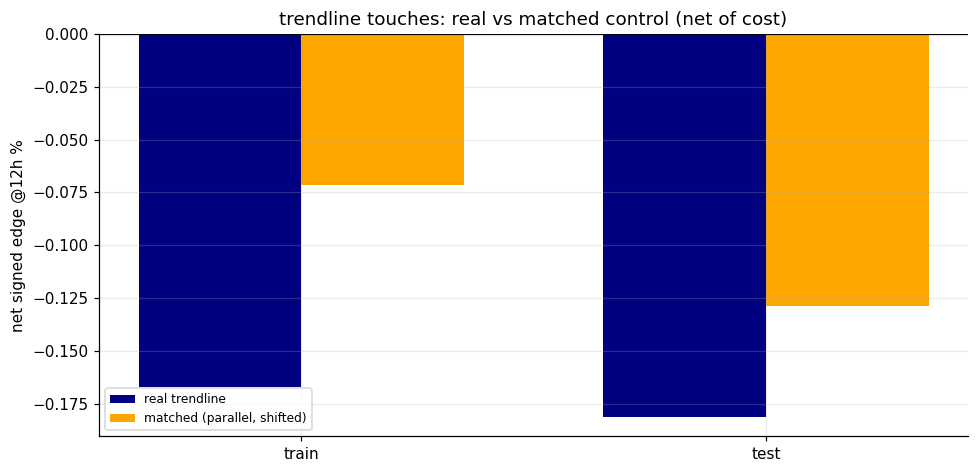

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.4))
piv = E.groupby(["period","kind"]).h12.apply(lambda s:(s.mean()-COST)*100).unstack()
piv = piv.reindex(["train","test"])
x = np.arange(len(piv)); w = 0.35
ax.bar(x - w/2, piv["real"], w, color="navy", label="real trendline")
ax.bar(x + w/2, piv["matched"], w, color="orange", label="matched (parallel, shifted)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(piv.index); ax.set_ylabel("net signed edge @12h %")
ax.set_title("trendline touches: real vs matched control (net of cost)"); ax.legend(fontsize=8)
show("10_trendline_edge")

## Verdict

- real > matched и > 0 на ОБА периода → наклонки несут эффект сверх «просто наклонный
  луч в тренде». Если real ≈ matched или edge есть только на train → как горизонтальные:
  диагональный уровень сам по себе не торгуем в OHLCV.
- Сторона (up support / down resist) разбита отдельно — вдруг работает только одна.